## Sensitivity of Large-Scale Advections in the Trade-Wind Cumulus Model
- This Jupyter Notebook uses re-analysis datasets (ERA5) to investigate the large-scale terms in the diagnostic model.

### Python packages

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import dask
import pandas as pd
import re

from pathlib import Path
from joblib import Memory, Parallel, delayed
from datetime import datetime

### Functions

In [2]:
def decode_files_time(name: str):
    # ERA5 u & v files
    m = re.search(rf".*\.(\d{{10}})_(\d{{10}})\.nc$", name, re.IGNORECASE)
    if m:
        fstart = datetime.strptime(m.group(1), "%Y%m%d%H")
        fend = datetime.strptime(m.group(2), "%Y%m%d%H")
        return fstart, fend
    return None

def find_filenames(directory, keyword, qstart, qend):
    fdir = Path(directory)
    files = []
    for fn in fdir.rglob("*"):
        if not fn.is_file():
            continue
        
        # Keyword used to filter file names
        fname = fn.name
        if keyword == "133_q" and "133_q" not in fname:
            continue
        if keyword == "130_t" and "130_t" not in fname:
            continue
        if keyword == "131_u" and "131_u" not in fname:
            continue
        if keyword == "132_v" and "132_v" not in fname:
            continue
        if keyword == "135_w" and "135_w" not in fname:
            continue
        if keyword == "129_z" and "129_z" not in fname:
            continue

        # Finding correct files
        ftime = decode_files_time(fn.name)
        if ftime is None:
            continue
        fstart, fend = ftime
        if fstart <= qend and fend >= qstart:
            files.append(fn)
    return sorted(files)

def parallel_worker(file, region_bound, var, spatialavg=False, timesample=False, spacesample=False):
    # Region bound
    lonmin, lonmax = region_bound[0], region_bound[1] # degrees East
    latmin, latmax = region_bound[2], region_bound[3] # degrees North
    levmin, levmax = region_bound[4], region_bound[5] # hPa
    
    ds = xr.open_dataset(file)
    
    try:
        # ---- NEW: keep only 0,3,6,9,12,15,18,21 UTC ----
        if timesample:
            ds = ds.sel(time=ds.time.dt.hour.isin([0, 3, 6, 9, 12, 15, 18, 21]))
            # ds = ds.sel(time=ds.time.dt.hour.isin([0, 2, 4, 6, 8, 10, 12 ,14, 16, 18, 20, 22]))

        varin = ds[var].sel(longitude=slice(lonmin, lonmax),
                            latitude=slice(latmax, latmin),
                            level=slice(levmin, levmax))

        if spacesample:
            varin = varin.isel(longitude=slice(None, None, 2), latitude=slice(None, None, 2))

        if spatialavg:
            weights = np.cos(np.radians(ds.latitude))
            varavg  = varin.weighted(weights).mean(dim=("longitude", "latitude")).squeeze()
        else:
            varavg = varin

        return varavg.values

    finally:
        ds.close()


def parallel_worker_advq(qfile, ufile, vfile, region_bound, qname="Q", uname="U", vname="V", spatialavg=False, timesample=False, spacesample=False):
    # Region bound
    lonmin, lonmax = region_bound[0], region_bound[1] # degrees East
    latmin, latmax = region_bound[2], region_bound[3] # degrees North
    levmin, levmax = region_bound[4], region_bound[5] # hPa

    R = 6371000.0  # Earth radius (m)

    dsq = xr.open_dataset(qfile)
    dsu = xr.open_dataset(ufile)
    dsv = xr.open_dataset(vfile)

    try:
        # ---- NEW: keep only 0,3,6,9,12,15,18,21 UTC ----
        if timesample:
            dsq = dsq.sel(time=dsq.time.dt.hour.isin([0, 3, 6, 9, 12, 15, 18, 21]))
            dsu = dsu.sel(time=dsu.time.dt.hour.isin([0, 3, 6, 9, 12, 15, 18, 21]))
            dsv = dsv.sel(time=dsv.time.dt.hour.isin([0, 3, 6, 9, 12, 15, 18, 21]))
            # dsq = dsq.sel(time=dsq.time.dt.hour.isin([0, 2, 4, 6, 8, 10, 12 ,14, 16, 18, 20, 22]))
            # dsu = dsu.sel(time=dsu.time.dt.hour.isin([0, 2, 4, 6, 8, 10, 12 ,14, 16, 18, 20, 22]))
            # dsv = dsv.sel(time=dsv.time.dt.hour.isin([0, 2, 4, 6, 8, 10, 12 ,14, 16, 18, 20, 22]))
        
        # subset (keep latitude slice in the same direction you used)
        qin = dsq[qname].sel(longitude=slice(lonmin, lonmax),
                            latitude=slice(latmax, latmin),
                            level=slice(levmin, levmax))
        uin = dsu[uname].sel(longitude=slice(lonmin, lonmax),
                            latitude=slice(latmax, latmin),
                            level=slice(levmin, levmax))
        vin = dsv[vname].sel(longitude=slice(lonmin, lonmax),
                            latitude=slice(latmax, latmin),
                            level=slice(levmin, levmax))

        if spacesample:
            qin = qin.isel(longitude=slice(None, None, 2), latitude=slice(None, None, 2))
            uin = uin.isel(longitude=slice(None, None, 2), latitude=slice(None, None, 2))
            vin = vin.isel(longitude=slice(None, None, 2), latitude=slice(None, None, 2))

        # coords
        lat_rad = np.deg2rad(qin.latitude.values)   # (nlat,)
        lon_rad = np.deg2rad(qin.longitude.values)  # (nlon,)

        # grid spacing (meters)
        dlat = np.gradient(lat_rad)                 # (nlat,) radians
        dlon = np.gradient(lon_rad)                 # (nlon,) radians
        dy   = R * dlat                              # (nlat,) meters
        dx   = R * np.cos(lat_rad)[:, None] * dlon[None, :]  # (nlat, nlon) meters

        # numpy arrays: (time, level, lat, lon)
        q = qin.values
        u = uin.values
        v = vin.values

        # gradients (per meter)
        dq_dy = np.gradient(q, axis=-2) / dy[None, None, :, None]
        dq_dx = np.gradient(q, axis=-1) / dx[None, None, :, :]

        adv_q = -(u * dq_dx + v * dq_dy)  # kg/kg/s

        # area-weighted mean over lat/lon (cos(lat) weights)
        if spatialavg:
            wlat = np.cos(lat_rad)[:, None]                 # (nlat, 1)
            w2d  = np.broadcast_to(wlat, dx.shape)          # (nlat, nlon)
            num  = np.nansum(adv_q * w2d[None, None, :, :], axis=(-2, -1))
            den  = np.nansum(w2d)
            adv_q_avg = (num / den)                         # (time, level)
        else:
            adv_q_avg = adv_q

        return adv_q_avg

    finally:
        dsq.close()
        dsu.close()
        dsv.close()

In [3]:
# --- one profile ---
def interp_one(it, z, z_e5z, q_e5p, qadv_e5p, t_e5p, w_e5p, plev, T0):
    idx = np.argsort(z_e5z[it, :])
    zin = z_e5z[it, idx]
    return (
        np.interp(z, zin, q_e5p[it, idx]),
        np.interp(z, zin, qadv_e5p[it, idx]),
        np.interp(z, zin, t_e5p[it, idx] - T0),
        np.interp(z, zin, w_e5p[it, idx]),
        np.interp(z, zin, plev[idx]),   # NOTE: no [::-1]
    )

def interp_one_ls(it, z, z_e5z, ls_e5p, T0):
    idx = np.argsort(z_e5z[it, :])
    zin = z_e5z[it, idx]
    return (
        np.interp(z, zin, ls_e5p[it, idx]),
    )

# --- a chunk of profiles (this is the “unit of parallelism”) ---
def interp_chunk(i0, i1, z, z_e5z, q_e5p, qadv_e5p, t_e5p, w_e5p, plev, T0):
    nz = z.size
    out_q    = np.empty((i1 - i0, nz))
    out_qadv = np.empty((i1 - i0, nz))
    out_t    = np.empty((i1 - i0, nz))
    out_w    = np.empty((i1 - i0, nz))
    out_p    = np.empty((i1 - i0, nz))

    for k, it in enumerate(range(i0, i1)):
        out_q[k], out_qadv[k], out_t[k], out_w[k], out_p[k] = interp_one(
            it, z, z_e5z, q_e5p, qadv_e5p, t_e5p, w_e5p, plev, T0
        )
    return out_q, out_qadv, out_t, out_w, out_p

def interp_chunk_ls(i0, i1, z, z_e5z, ls_e5p, T0):
    nz = z.size
    out_ls    = np.empty((i1 - i0, nz))

    for k, it in enumerate(range(i0, i1)):
        out_ls[k] = interp_one_ls(
            it, z, z_e5z, ls_e5p, T0
        )
    return out_ls

### Constants

In [4]:
Rd = 287.05
g  = 9.80665
T0 = 273.15
dz = 10

### Data: open datasets and grab variables
We obtain environmental mean profiles of specific humidity, temperature, and pressure from the Ronald Brown ship sounding data while preciptiation rate, surface air density and temperature are from the surface measurements (Quinn et al., 2021; https://doi.org/10.5194/essd-13-1759-2021).
- https://www.ncei.noaa.gov/archive/accession/ATOMIC-2020
- The Atlantic Tradewind Ocean-Atmosphere Mesoscale Interaction Campaign (ATOMIC) was a field campaign held January-February 2020 in the tropical North Atlantic east of Barbados. The campaign, the U.S. complement to the European field campaign called EUREC4A, was aimed at better understanding cloud and air-sea interaction processes. ATOMIC included in measurements from a NOAA WP-3D Orion "Hurricane Hunter" aircraft, the research ship Ronald H. Brown, and unpiloted vehicles launched from Barbados and from the Ronald H. Brown.

### Time ranges for different datasets
- Soundings (Ron Brown):      Jan 08 to Feb 12, 2020
- Surface fluxes (Ron Brown): Jan 09 to Feb 12, 2020
- Satellite (GOES-16):        Jan 15 to Feb 19, 2020
- Reanalysis (ERA5):          Jan 01 to Mar 31, 2020

#### (1) Data from radiosondes

In [5]:
# Ronald Brown data
rdir = "/home/huangany/data/KloudatA/ATOMIC/RonBrown"

dsr  = xr.open_dataset(Path(rdir, "RonBrown_radiosondes.nc"))
# dss  = xr.open_dataset(Path(rdir, "RonBrown_10min_flux.nc"))

In [6]:
# Generate start and end time for ERA5 data
qstart = pd.to_datetime(dsr.launch_time.min().values).to_pydatetime()
qstart = datetime(qstart.year, qstart.month, qstart.day)

qend = pd.to_datetime(dsr.launch_time.max().values).to_pydatetime()
qend = datetime(qend.year, qend.month, qend.day)

# Cloud Botany
# qstart = datetime(2020, 1, 1, 0, 0)
# qend   = datetime(2020, 3, 31, 0, 0)

In [7]:
z    = dsr.alt      # m
p_rs = dsr.p        # Pa
t_rs = dsr.ta - T0  # C
q_rs = dsr.q        # kg/kg

# Time average
# tm_rs = rt.mean(axis=0) - T0
# qm_rs = rq.mean(axis=0) * 1000

#### (2) Data from reanalysis

In [8]:
# ERA5
edir   = "/home/huangany/data/KloudatA/ERA5/1hr/PRS"

# qfiles = sorted((Path(edir, "q")).glob("*/*.nc"))
# tfiles = sorted((Path(edir, "t")).glob("*/*.nc"))
# wfiles = sorted((Path(edir, "w")).glob("*/*.nc"))
# zfiles = sorted((Path(edir, "z")).glob("*/*.nc"))
qfiles = find_filenames(Path(edir, "q"), "133_q", qstart, qend)
tfiles = find_filenames(Path(edir, "t"), "130_t", qstart, qend)
wfiles = find_filenames(Path(edir, "w"), "135_w", qstart, qend)
zfiles = find_filenames(Path(edir, "z"), "129_z", qstart, qend)

# Define box limits (longitude and latitude): Atomic Field Campaign region
# region_bound = 300, 311, 12.5, 16, 200, 1000 # degrees East, North, hPa
region_bound = 297.78, 305.78, 9.8, 16.8, 200, 1000 # Cloud Botany degrees East, North, hPa

# Spatial averaging
spatialavg = False

plev = xr.open_dataset(zfiles[0]).level.sel(level=slice(region_bound[4], region_bound[5])).load()

# Specific humidity (q: kg/kg)
print("Extracting Q")
q_start = datetime.now()
results = Parallel(n_jobs=30)(
    delayed(parallel_worker)(file, region_bound, var="Q", spatialavg = False, timesample=True, spacesample=True)
    for file in qfiles
)
oq_e5p = np.concatenate(results, axis=0)
q_end = datetime.now()
print(f"Calculation elapsed: {q_end - q_start}")

# Temperature (t: K)
print("Extracting T")
t_start = datetime.now()
results = Parallel(n_jobs=30)(
    delayed(parallel_worker)(file, region_bound, var="T", spatialavg = False, timesample=True, spacesample=True)
    for file in tfiles
)
ot_e5p = np.concatenate(results, axis=0)
t_end = datetime.now()
print(f"Calculation elapsed: {t_end - t_start}")

# Vertical velocity (Omega: Pa/s)
print("Extracting W (omega: Pa/s)")
o_start = datetime.now()
results = Parallel(n_jobs=30)(
    delayed(parallel_worker)(file, region_bound, var="W", spatialavg = False, timesample=True, spacesample=True)
    for file in wfiles
)
oo_e5p = np.concatenate(results, axis=0)
o_end = datetime.now()
print(f"Calculation elapsed: {o_end - o_start}")

# Geopotential height (gz: m^2/s^2)
print("Extracting Z")
z_start = datetime.now()
results = Parallel(n_jobs=30)(
    delayed(parallel_worker)(file, region_bound, var="Z", spatialavg = False, timesample=True, spacesample=True)
    for file in zfiles
)
oz_e5p = np.concatenate(results, axis=0)
z_end = datetime.now()
print(f"Calculation elapsed: {z_end - z_start}")


Extracting Q
Calculation elapsed: 0:00:15.013561
Extracting T
Calculation elapsed: 0:00:13.381348
Extracting W (omega: Pa/s)
Calculation elapsed: 0:00:14.363807
Extracting Z
Calculation elapsed: 0:00:12.595129


In [9]:
ufiles = find_filenames(Path(edir, "u"), "131_u", qstart, qend)
vfiles = find_filenames(Path(edir, "v"), "132_v", qstart, qend)

# Horizontal advection (Q, U, V)
print("Extracting Q, U, V and calculating horizontal moisture advection")
qadv_start = datetime.now()
results = Parallel(n_jobs=30)(
    delayed(parallel_worker_advq)(qf, uf, vf, region_bound, qname="Q", uname="U", vname="V", spatialavg = False, timesample=True, spacesample=True)
    for qf, uf, vf in zip(qfiles, ufiles, vfiles)
)
oqadv_e5p = np.concatenate(results, axis=0)  # (time_all, level)
qadv_end = datetime.now()
print(f"Calculation elapsed: {qadv_end - qadv_start}")


Extracting Q, U, V and calculating horizontal moisture advection
Calculation elapsed: 0:00:45.680341


In [10]:
if spatialavg:
    q_e5p = oq_e5p
    t_e5p = ot_e5p
    o_e5p = oo_e5p
    z_e5p = oz_e5p
    qadv_e5p = oqadv_e5p
else:
    q_e5p = np.moveaxis(oq_e5p, 1, -1).reshape(-1, 23)
    t_e5p = np.moveaxis(ot_e5p, 1, -1).reshape(-1, 23)
    o_e5p = np.moveaxis(oo_e5p, 1, -1).reshape(-1, 23)
    z_e5p = np.moveaxis(oz_e5p, 1, -1).reshape(-1, 23)
    qadv_e5p = np.moveaxis(oqadv_e5p, 1, -1).reshape(-1, 23)

In [11]:
# Convert omega to vertical velocity (keep time dimension)
tv_e5p = t_e5p * (1.0 + 0.61 * q_e5p)
w_e5p  = -o_e5p * Rd * tv_e5p / (g * (plev.values*100))

# # z in meters (time, lev)
z_e5z  = z_e5p / g

# Allocate arrays on z grid
if spatialavg:
    nt     = q_e5p.shape[0]
    q_e5z  = np.full((nt, z.size), np.nan)
    qadv_e5z  = np.full((nt, z.size), np.nan)
    t_e5z  = np.full((nt, z.size), np.nan)
    w_e5z  = np.full((nt, z.size), np.nan)
    p_e5z  = np.full((nt, z.size), np.nan)

    for it in range(nt):
        # Sort by height for this time
        idx = np.argsort(z_e5z[it, :])
        zin = z_e5z[it, idx]

        # Interpolate onto common z grid
        q_e5z[it, :] = np.interp(z, zin, (q_e5p[it, idx]))      # kg/kg
        qadv_e5z[it, :] = np.interp(z, zin, (qadv_e5p[it, idx]))   # kg/kg/s
        t_e5z[it, :] = np.interp(z, zin, (t_e5p[it, idx] - T0)) # C
        w_e5z[it, :] = np.interp(z, zin, (w_e5p[it, idx]))      # m/s
        p_e5z[it, :] = np.interp(z, zin, (plev[::-1][idx]))     # hPa
else:
    nt = min(z_e5z.shape[0], q_e5p.shape[0], qadv_e5p.shape[0], t_e5p.shape[0], w_e5p.shape[0])
    chunk = 2000  # adjust (1000–10000 typically)
    chunks = [(i, min(i + chunk, nt)) for i in range(0, nt, chunk)]

    print("Converting to z coordinates")
    cz_start = datetime.now()
    results = Parallel(n_jobs=30)(
        delayed(interp_chunk)(i0, i1, z, z_e5z, q_e5p, qadv_e5p, t_e5p, w_e5p, plev.values, T0)
        for (i0, i1) in chunks
    )

    q_e5z    = np.vstack([r[0] for r in results])
    qadv_e5z = np.vstack([r[1] for r in results])
    t_e5z    = np.vstack([r[2] for r in results])
    w_e5z    = np.vstack([r[3] for r in results])
    p_e5z    = np.vstack([r[4] for r in results])
    cz_end = datetime.now()
    print(f"Calculation elapsed: {cz_end - cz_start}")

Converting to z coordinates
Calculation elapsed: 0:00:34.525624


### Calculations

#### Vertical moisture advection

In [12]:
# Vertical gradient of specific humidity
dqdz_rs  = np.diff(q_rs, axis=1) / dz # kg/kg/m
dqdz_e5z = np.diff(q_e5z, axis=1) / dz

# Vertical velocity (idealized in Cloud Botany LES)
# w_scale  = -0.0045  # Background subsidence velocity [m/s]
w_scale  = np.array([-0.0045, -0.012])  # Background subsidence velocity [m/s]
h_scale  = 2500     # Scale height of background subsidence [m]: determine how fast the velocity decreases to 0 at surface
w1       = 0.000393 # m/s
hw1      = 5300     # m
ihw1     = np.where(z == hw1)[0][0]

w_idl    = w_scale[:, None] * (1 - np.exp(-z.values/h_scale)) # Hadley term
w_idg    = w_idl.copy()
w_idg[:, :ihw1] = w_idg[:, :ihw1] + w1 * np.sin(2*np.pi*z[:ihw1].values/hw1) # Hadley + Mesoscale terms

# Simon's
divg     = 1.5e-6   # Divergence of vertical velocity [s^-1]
zi       = 4000   # Inversion height [m]
w_smn    = -divg * np.minimum(z.values, zi)

# Vertical advection
wdqdz_rs  = -w_idl[:, None, :-1] * dqdz_rs[None, :, :]
wdqdz_rsg = -w_idg[:, None, :-1] * dqdz_rs[None, :, :]
wdqdz_rss = -w_smn[None, :-1] * dqdz_rs
wdqdz_e5z = -w_e5z[:, :-1] * dqdz_e5z


In [13]:
dp = np.diff(plev.values*100)
dqdp_e5p = np.diff(q_e5p, axis=1) / dp # kg/kg/Pa
wdqdp_e5p = -w_e5p[:, :-1] * dqdp_e5p

In [29]:
wdqdp_e5p.shape

(64512, 22)

#### Horizontal moisture advection

In [14]:
# Horizontal advection (idealized in Cloud Botany LES)
dqdt     = -1.49   # Large-scale humidity tendency at surface [g/kg/day]
dqdtdz   = 3.73e-4 # Large-scale humidity tendency slope [g/kg/day/m]

qadv_idl = dqdt + dqdtdz * z
qadv_idl = np.where(qadv_idl < 0, qadv_idl, 0)/1000/86400 # kg/kg/s

# Simon's
ztop     = 4000   # Top of trade cumulus cloud layer [m]
qadv_smn = -1.7e-8 * np.maximum(0, (ztop - z)/ztop)

#### Total large-scale moisture advection

In [15]:
ls_rs  = qadv_idl[:-1] + wdqdz_rs
ls_rsg = qadv_idl[:-1] + wdqdz_rsg
ls_rss = qadv_idl[:-1] + wdqdz_rss
# ls_e5z = qadv_e5z[:, :-1] + wdqdz_e5z

In [16]:
ls_e5p = qadv_e5p[:, :-1] + wdqdp_e5p
ls_e5p.shape

(64512, 22)

In [17]:
# z in meters (time, lev)
z_mid = (z.values[:-1].astype(float) + z.values[1:].astype(float)) / 2
z_e5z  = (z_e5p[:, :-1] + z_e5p[:, 1:]) / 2 / g

# Allocate arrays on z grid
nt     = ls_e5p.shape[0]
ls_e5z  = np.full((nt, z_mid.size), np.nan)

for it in range(nt):
    # Sort by height for this time
    idx = np.argsort(z_e5z[it, :])
    zin = z_e5z[it, idx]

    # Interpolate onto common z grid
    ls_e5z[it, :] = np.interp(z_mid, zin, (ls_e5p[it, idx]))

#### Total moisture flux

In [21]:
iz8  = np.where(z == 8000)[0][0]
F_rs = -np.flip(np.nancumsum(np.flip(ls_rs[:,:,:iz8] * dz, axis=2), axis=2), axis=2)
F_rsg = -np.flip(np.nancumsum(np.flip(ls_rsg[:,:,:iz8] * dz, axis=2), axis=2), axis=2)
F_rss = -np.flip(np.nancumsum(np.flip(ls_rss[:,:iz8] * dz, axis=1), axis=1), axis=1)
F_e5z = -np.flip(np.nancumsum(np.flip(ls_e5z[:,:iz8] * dz, axis=1), axis=1), axis=1)

#### Time average & percentiles

In [22]:
# Average along axis=0 (time)
qm_rs       = np.nanmean(q_rs, axis=0)
tm_rs       = np.nanmean(t_rs, axis=0)
pm_rs       = np.nanmean(p_rs, axis=0)
dqdzm_rs    = np.nanmean(dqdz_rs, axis=0)
wdqdzm_rss  = np.nanmean(wdqdz_rss, axis=0)
wdqdzm_rs   = np.nanmean(wdqdz_rs, axis=1)
wdqdzm_rsg  = np.nanmean(wdqdz_rsg, axis=1)
lsm_rs      = np.nanmean(ls_rs, axis=1)
lsm_rsg     = np.nanmean(ls_rsg, axis=1)
lsm_rss     = np.nanmean(ls_rss, axis=0)
Fm_rs       = np.nanmean(F_rs, axis=1)
Fm_rsg      = np.nanmean(F_rsg, axis=1)
Fm_rss      = np.nanmean(F_rss, axis=0)

qm_e5z      = np.nanmean(q_e5z, axis=0)
tm_e5z      = np.nanmean(t_e5z, axis=0)
wm_e5z      = np.nanmean(w_e5z, axis=0)
pm_e5z      = np.nanmean(p_e5z, axis=0)
dqdzm_e5z   = np.nanmean(dqdz_e5z, axis=0)
wdqdzm_e5z  = np.nanmean(wdqdz_e5z, axis=0)
qadvm_e5z   = np.nanmean(qadv_e5z, axis=0)
lsm_e5z     = np.nanmean(ls_e5z, axis=0)
Fm_e5z      = np.nanmean(F_e5z, axis=0)

# Percentiles along axis=0 (time)
qpt_rs      = np.nanpercentile(q_rs, [2.5, 25, 50, 75, 97.5], axis=0)
tpt_rs      = np.nanpercentile(t_rs, [2.5, 25, 50, 75, 97.5], axis=0)
ppt_rs      = np.nanpercentile(p_rs, [2.5, 25, 50, 75, 97.5], axis=0)
dqdzpt_rs   = np.nanpercentile(dqdz_rs, [2.5, 25, 50, 75, 97.5], axis=0)
wdqdzpt_rss = np.nanpercentile(wdqdz_rss, [2.5, 25, 50, 75, 97.5], axis=0)
wdqdzpt_rs  = np.nanpercentile(wdqdz_rs, [2.5, 25, 50, 75, 97.5], axis=1)
wdqdzpt_rsg = np.nanpercentile(wdqdz_rsg, [2.5, 25, 50, 75, 97.5], axis=1)
lspt_rs     = np.nanpercentile(ls_rs, [2.5, 25, 50, 75, 97.5], axis=1)
lspt_rsg    = np.nanpercentile(ls_rsg, [2.5, 25, 50, 75, 97.5], axis=1)
lspt_rss    = np.nanpercentile(ls_rss, [2.5, 25, 50, 75, 97.5], axis=0)
Fpt_rs      = np.nanpercentile(F_rs, [2.5, 25, 50, 75, 97.5], axis=1)
Fpt_rsg     = np.nanpercentile(F_rsg, [2.5, 25, 50, 75, 97.5], axis=1)
Fpt_rss     = np.nanpercentile(F_rss, [2.5, 25, 50, 75, 97.5], axis=0)

qpt_e5z     = np.nanpercentile(q_e5z, [2.5, 25, 50, 75, 97.5], axis=0)
tpt_e5z     = np.nanpercentile(t_e5z, [2.5, 25, 50, 75, 97.5], axis=0)
wpt_e5z     = np.nanpercentile(w_e5z, [2.5, 25, 50, 75, 97.5], axis=0)
ppt_e5z     = np.nanpercentile(p_e5z, [2.5, 25, 50, 75, 97.5], axis=0)
dqdzpt_e5z  = np.nanpercentile(dqdz_e5z, [2.5, 25, 50, 75, 97.5], axis=0)
wdqdzpt_e5z = np.nanpercentile(wdqdz_e5z, [2.5, 25, 50, 75, 97.5], axis=0)
qadvpt_e5z  = np.nanpercentile(qadv_e5z, [2.5, 25, 50, 75, 97.5], axis=0)
lspt_e5z    = np.nanpercentile(ls_e5z, [2.5, 25, 50, 75, 97.5], axis=0)
Fpt_e5z     = np.nanpercentile(F_e5z, [2.5, 25, 50, 75, 97.5], axis=0)


/tmp/ipykernel_943255/3199388030.py:2: RuntimeWarning: Mean of empty slice
  qm_rs       = np.nanmean(q_rs, axis=0)
/tmp/ipykernel_943255/3199388030.py:3: RuntimeWarning: Mean of empty slice
  tm_rs       = np.nanmean(t_rs, axis=0)
/tmp/ipykernel_943255/3199388030.py:4: RuntimeWarning: Mean of empty slice
  pm_rs       = np.nanmean(p_rs, axis=0)
/tmp/ipykernel_943255/3199388030.py:5: RuntimeWarning: Mean of empty slice
  dqdzm_rs    = np.nanmean(dqdz_rs, axis=0)
/tmp/ipykernel_943255/3199388030.py:6: RuntimeWarning: Mean of empty slice
  wdqdzm_rss  = np.nanmean(wdqdz_rss, axis=0)
/tmp/ipykernel_943255/3199388030.py:7: RuntimeWarning: Mean of empty slice
  wdqdzm_rs   = np.nanmean(wdqdz_rs, axis=1)
/tmp/ipykernel_943255/3199388030.py:8: RuntimeWarning: Mean of empty slice
  wdqdzm_rsg  = np.nanmean(wdqdz_rsg, axis=1)
/tmp/ipykernel_943255/3199388030.py:9: RuntimeWarning: Mean of empty slice
  lsm_rs      = np.nanmean(ls_rs, axis=1)
/tmp/ipykernel_943255/3199388030.py:10: RuntimeWarning

### Plots

#### Q, T, W

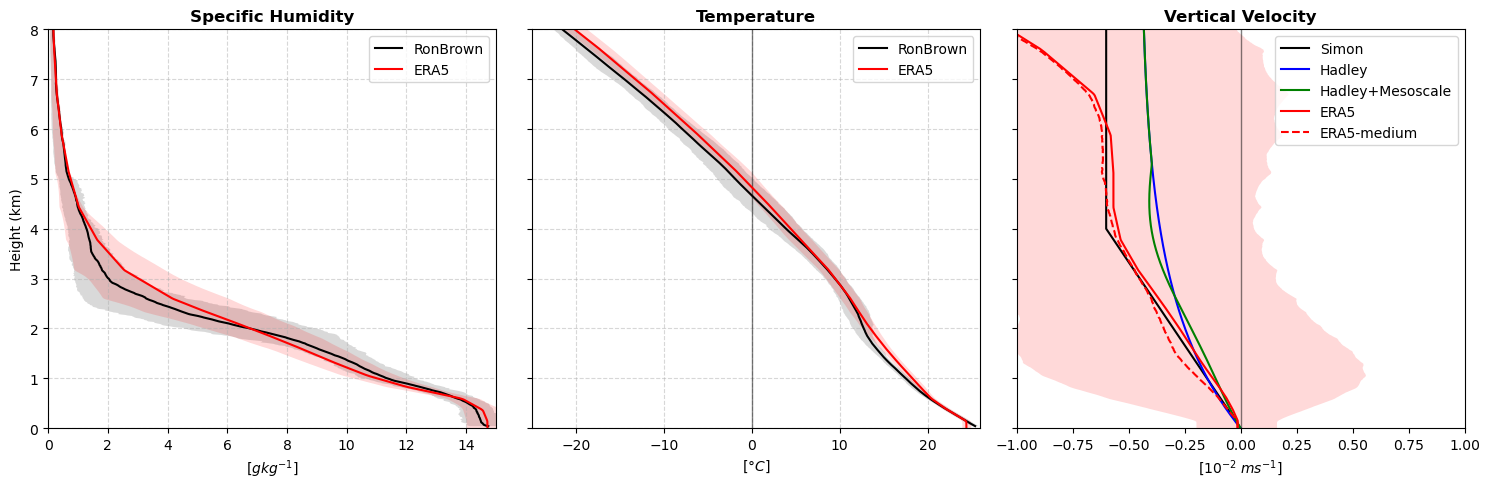

In [23]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

# -------------------- (1) q --------------------
ax = axs[0]
ax.fill_betweenx(z/1000, qpt_rs[1, :]*1000, qpt_rs[3, :]*1000, color='k', alpha=0.15, edgecolor='none')
ax.plot(qm_rs*1000, z/1000, 'k-', label='RonBrown')

ax.fill_betweenx(z/1000, qpt_e5z[1, :]*1000, qpt_e5z[3, :]*1000, color='r', alpha=0.15, edgecolor='none')
ax.plot(qm_e5z*1000, z/1000, 'r-', label='ERA5')

ax.set_yticks(np.arange(0, 20, 1))
ax.set_xlim(0, 15)
ax.set_ylim(0, 8)

ax.set_xlabel("[$gkg^{-1}]$")
ax.set_ylabel("Height (km)")
ax.set_title("Specific Humidity", fontweight='bold')
ax.legend()

ax.grid(linestyle='--', alpha=0.5)
# ax.grid(axis='x', linestyle='-', alpha=0.5)
# ax.grid(axis='y', color='r', linestyle='--', alpha=0.5)

# -------------------- (2) T --------------------
ax = axs[1]
ax.axvline(0, linewidth=1, color='k', alpha=0.5)
ax.fill_betweenx(z/1000, tpt_rs[1, :], tpt_rs[3, :], color='k', alpha=0.15, edgecolor='none')
ax.plot(tm_rs, z/1000, 'k-', label='RonBrown')

ax.fill_betweenx(z/1000, tpt_e5z[1, :], tpt_e5z[3, :], color='r', alpha=0.15, edgecolor='none')
ax.plot(tm_e5z, z/1000, 'r-', label='ERA5')

ax.set_yticks(np.arange(0, 20, 1))
ax.set_xlim(-25, 26)
ax.set_ylim(0, 8)

ax.set_xlabel("[$\degree C$]")
ax.set_title("Temperature", fontweight='bold')
ax.legend()

ax.grid(linestyle='--', alpha=0.5)

# -------------------- (3) W --------------------
ax = axs[2]
ax.axvline(0, linewidth=1, color='k', alpha=0.5)
ax.plot(w_smn*1e2, z/1000, 'k-', label='Simon')
ax.plot(w_idl[0, :]*1e2, z/1000, 'b-', label='Hadley')
ax.plot(w_idg[0, :]*1e2, z/1000, 'g-', label='Hadley+Mesoscale')
# ax.plot(w_idl[1, :]*1e2, z/1000, 'b--')
# ax.plot(w_idg[1, :]*1e2, z/1000, 'g--')

ax.fill_betweenx(z/1000, wpt_e5z[1, :]*1e2, wpt_e5z[3, :]*1e2, color='r', alpha=0.15, edgecolor='none')
ax.plot(wm_e5z*1e2, z/1000, 'r-', label='ERA5')
ax.plot(wpt_e5z[2, :]*1e2, z/1000, 'r--', label='ERA5-medium')

ax.set_yticks(np.arange(0, 20, 1))
ax.set_xlim(-1, 1)
ax.set_ylim(0, 8)

# ax.set_xlabel(r"$\omega$ (Pa s$^{-1}$)")
ax.set_xlabel("[$10^{-2}$ $ms^{-1}$]")
ax.set_title("Vertical Velocity", fontweight='bold')
ax.legend()

plt.tight_layout()
plt.show()


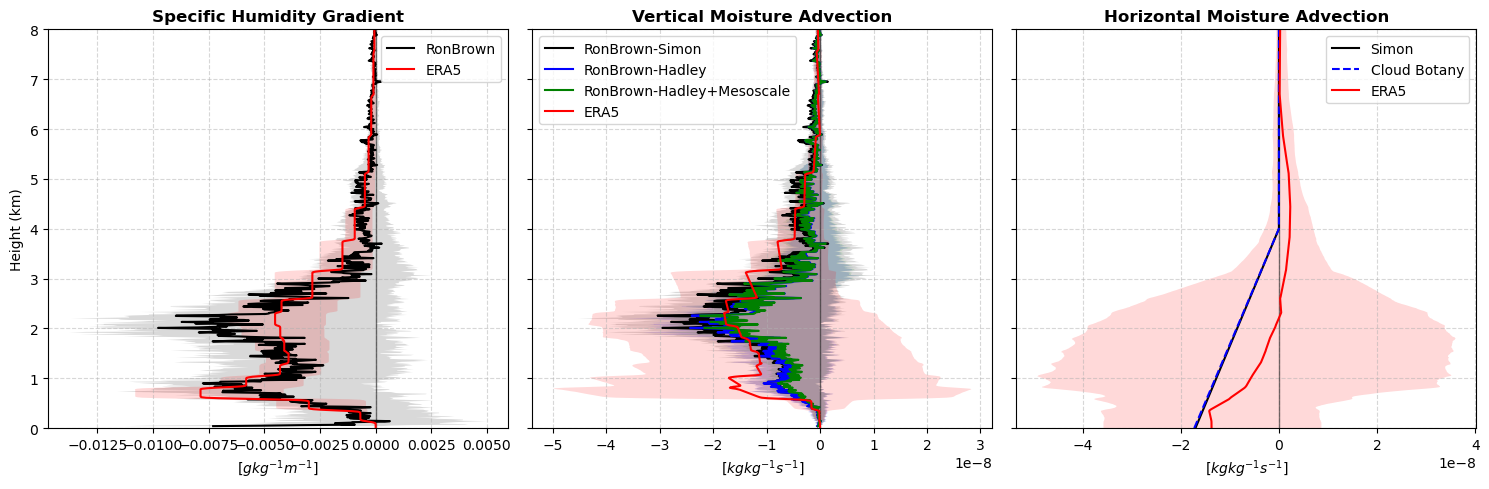

In [24]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

# -------------------- (1) dqdz --------------------
ax = axs[0]
ax.axvline(0, linewidth=1, color='k', alpha=0.5)
ax.fill_betweenx(z[:-1]/1000, dqdzpt_rs[1, :]*1000, dqdzpt_rs[3, :]*1000, color='k', alpha=0.15, edgecolor='none')
ax.plot(dqdzm_rs*1000, z[:-1]/1000, 'k-', label='RonBrown')

ax.fill_betweenx(z[:-1]/1000, dqdzpt_e5z[1, :]*1000, dqdzpt_e5z[3, :]*1000, color='r', alpha=0.15, edgecolor='none')
ax.plot(dqdzm_e5z*1000, z[:-1]/1000, 'r-', label='ERA5')

# ax.set_yticks(np.arange(0, 20, 1))
# ax.set_xlim(0, 15)
ax.set_ylim(0, 8)

ax.set_xlabel("[$gkg^{-1}m^{-1}$]")
ax.set_ylabel("Height (km)")
ax.set_title("Specific Humidity Gradient", fontweight='bold')
ax.legend()

ax.grid(linestyle='--', alpha=0.5)
# ax.grid(axis='x', linestyle='-', alpha=0.5)
# ax.grid(axis='y', color='r', linestyle='--', alpha=0.5)

# -------------------- (2) Wdq/dz --------------------
ax = axs[1]
ax.axvline(0, linewidth=1, color='k', alpha=0.5)
ax.fill_betweenx(z[:-1]/1000, wdqdzpt_rss[1, :], wdqdzpt_rss[3, :], color='k', alpha=0.15, edgecolor='none')
ax.plot(wdqdzm_rss, z[:-1]/1000, 'k-', label='RonBrown-Simon')
ax.fill_betweenx(z[:-1]/1000, wdqdzpt_rs[1, 0, :], wdqdzpt_rs[3, 0, :], color='b', alpha=0.15, edgecolor='none')
ax.plot(wdqdzm_rs[0, :], z[:-1]/1000, 'b-', label='RonBrown-Hadley')
# ax.plot(wdqdzm_rs[1, :], z[:-1]/1000, 'b--', linewidth=0.8)
ax.fill_betweenx(z[:-1]/1000, wdqdzpt_rsg[1, 0, :], wdqdzpt_rsg[3, 0, :], color='g', alpha=0.15, edgecolor='none')
ax.plot(wdqdzm_rsg[0, :], z[:-1]/1000, 'g-', label='RonBrown-Hadley+Mesoscale')
# ax.plot(wdqdzm_rsg[1, :], z[:-1]/1000, 'g--', liewidth=0.8)

ax.fill_betweenx(z[:-1]/1000, wdqdzpt_e5z[1, :], wdqdzpt_e5z[3, :], color='r', alpha=0.15, edgecolor='none')
ax.plot(wdqdzm_e5z, z[:-1]/1000, 'r-', label='ERA5')

# ax.set_yticks(np.arange(0, 20, 1))
# ax.set_xlim(-25, 26)
ax.set_ylim(0, 8)

ax.set_xlabel("[$kg kg^{-1} s^{-1}$]")
ax.set_title("Vertical Moisture Advection", fontweight='bold')
ax.legend()

ax.grid(linestyle='--', alpha=0.5)

# -------------------- (3) Horizontal adv --------------------
ax = axs[2]
ax.axvline(0, linewidth=1, color='k', alpha=0.5)
ax.plot(qadv_smn, z/1000, 'k-', label='Simon')
ax.plot(qadv_idl, z/1000, 'b--', label='Cloud Botany')

ax.fill_betweenx(z/1000, qadvpt_e5z[1, :], qadvpt_e5z[3, :], color='r', alpha=0.15, edgecolor='none')
ax.plot(qadvm_e5z, z/1000, 'r-', label='ERA5')

ax.set_ylim(0, 8)

ax.set_xlabel("[$kg kg^{-1} s^{-1}$]")
ax.set_title("Horizontal Moisture Advection", fontweight='bold')
ax.legend()

ax.grid(linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


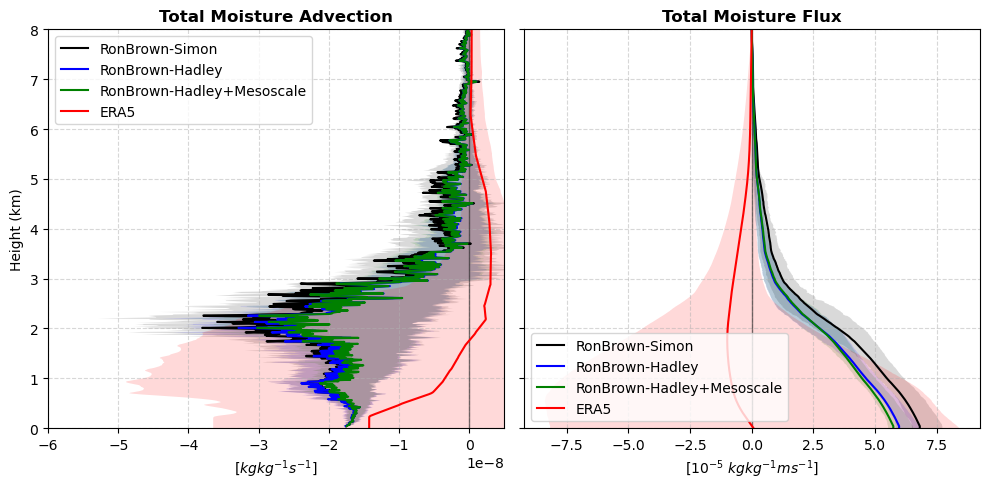

In [25]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5), sharey=True)

# -------------------- (1) LS total --------------------
ax = axs[0]
ax.axvline(0, linewidth=1, color='k', alpha=0.5)
ax.fill_betweenx(z[:-1]/1000, lspt_rss[1, :], lspt_rss[3, :], color='k', alpha=0.15, edgecolor='none')
ax.plot(lsm_rss, z[:-1]/1000, 'k-', label='RonBrown-Simon')

ax.fill_betweenx(z[:-1]/1000, lspt_rs[1, 0, :], lspt_rs[3, 0, :], color='b', alpha=0.15, edgecolor='none')
ax.plot(lsm_rs[0, :], z[:-1]/1000, 'b-', label='RonBrown-Hadley')
# ax.plot(lsm_rs[1, :], z[:-1]/1000, 'b--', linewidth=0.8)

ax.fill_betweenx(z[:-1]/1000, lspt_rsg[1, 0, :], lspt_rsg[3, 0, :], color='g', alpha=0.15, edgecolor='none')
ax.plot(lsm_rsg[0, :], z[:-1]/1000, 'g-', label='RonBrown-Hadley+Mesoscale')
# ax.plot(lsm_rsg[1, :], z[:-1]/1000, 'g--', linewidth=0.8)

ax.fill_betweenx(z[:-1]/1000, lspt_e5z[1, :], lspt_e5z[3, :], color='r', alpha=0.15, edgecolor='none')
ax.plot(lsm_e5z, z[:-1]/1000, 'r-', label='ERA5')

# ax.set_yticks(np.arange(0, 20, 1))
ax.set_xlim(-6e-8, 0.5e-8)
ax.set_ylim(0, 8)

ax.set_xlabel("[$kg kg^{-1} s^{-1}$]")
ax.set_ylabel("Height (km)")
ax.set_title("Total Moisture Advection", fontweight='bold')
ax.legend()

ax.grid(linestyle='--', alpha=0.5)
# ax.grid(axis='x', linestyle='-', alpha=0.5)
# ax.grid(axis='y', color='r', linestyle='--', alpha=0.5)

# -------------------- (2) LS cumsum --------------------
ax = axs[1]
ax.axvline(0, linewidth=1, color='k', alpha=0.5)
ax.fill_betweenx(z[:iz8]/1000, Fpt_rss[1, :]*1e5, Fpt_rss[3, :]*1e5, color='k', alpha=0.15, edgecolor='none')
ax.plot(Fm_rss*1e5, z[:iz8]/1000, 'k-', label='RonBrown-Simon')

ax.fill_betweenx(z[:iz8]/1000, Fpt_rs[1, 0, :]*1e5, Fpt_rs[3, 0, :]*1e5, color='b', alpha=0.15, edgecolor='none')
ax.plot(Fm_rs[0, :]*1e5, z[:iz8]/1000, 'b-', label='RonBrown-Hadley')
# ax.plot(Fm_rs[1, :]*1e5, z[:iz8]/1000, 'b--', linewidth=0.8)

ax.fill_betweenx(z[:iz8]/1000, Fpt_rsg[1, 0, :]*1e5, Fpt_rsg[3, 0, :]*1e5, color='g', alpha=0.15, edgecolor='none')
ax.plot(Fm_rsg[0, :]*1e5, z[:iz8]/1000, 'g-', label='RonBrown-Hadley+Mesoscale')
# ax.plot(Fm_rsg[1, :]*1e5, z[:iz8]/1000, 'g--', linewidth=0.8)

ax.fill_betweenx(z[:iz8]/1000, Fpt_e5z[1, :]*1e5, Fpt_e5z[3, :]*1e5, color='r', alpha=0.15, edgecolor='none')
ax.plot(Fm_e5z*1e5, z[:iz8]/1000, 'r-', label='ERA5')

# ax.set_yticks(np.arange(0, 20, 1))
# ax.set_xlim(-25, 26)
ax.set_ylim(0, 8)

ax.set_xlabel("[$10^{-5}$ $kg kg^{-1} ms^{-1}$]")
ax.set_title("Total Moisture Flux", fontweight='bold')
ax.legend()

ax.grid(linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()